In [1]:
import os, time
t = time.time()
print(os.listdir("/kaggle/input"))
print(round(time.time() - t, 2), "seconds")

['coco-2017-dataset']
0.0 seconds


In [2]:
import json, time

base = "/kaggle/input/coco-2017-dataset/coco2017"
t = time.time()
with open(base + "/annotations/instances_val2017.json") as f:
    val = json.load(f)

cat_ids = sorted(c["id"] for c in val["categories"])
print("classes:", len(cat_ids), "| first ids:", cat_ids[:5], "| last id:", cat_ids[-1])
print("val images:", len(val["images"]), "| annotations:", len(val["annotations"]))

img = val["images"][0]
p = f"{base}/val2017/{img['file_name']}"
print(p)
print("file exists:", os.path.exists(p))
print(round(time.time() - t, 2), "seconds")

classes: 80 | first ids: [1, 2, 3, 4, 5] | last id: 90
val images: 5000 | annotations: 36781
/kaggle/input/coco-2017-dataset/coco2017/val2017/000000397133.jpg
file exists: True
0.81 seconds


In [3]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# map COCO ids (1..90) to indices 0..79
cat_to_idx = {cid: i for i, cid in enumerate(cat_ids)}

# build multi-hot labels for every val image
img_ids = [im["id"] for im in val["images"]]
id_to_row = {iid: r for r, iid in enumerate(img_ids)}
Y_val = np.zeros((len(img_ids), 80), dtype=np.float32)
for ann in val["annotations"]:
    Y_val[id_to_row[ann["image_id"]], cat_to_idx[ann["category_id"]]] = 1.0

print("Y_val shape:", Y_val.shape)
print("avg classes per image:", round(Y_val.sum(1).mean(), 2))
print("images with no labels:", int((Y_val.sum(1) == 0).sum()))

# the old metric (per-label accuracy) for a model that predicts "nothing" everywhere
baseline_acc = 1 - Y_val.mean()
print("all-zeros baseline accuracy:", round(baseline_acc * 100, 2), "%")

Y_val shape: (5000, 80)
avg classes per image: 2.93
images with no labels: 48
all-zeros baseline accuracy: 96.34 %


In [4]:
t = time.time()
with open(base + "/annotations/instances_train2017.json") as f:
    tr = json.load(f)

tr_ids = [im["id"] for im in tr["images"]]
tr_files = [f"{base}/train2017/{im['file_name']}" for im in tr["images"]]
tr_row = {iid: r for r, iid in enumerate(tr_ids)}

Y_all = np.zeros((len(tr_ids), 80), dtype=np.float32)
for ann in tr["annotations"]:
    Y_all[tr_row[ann["image_id"]], cat_to_idx[ann["category_id"]]] = 1.0
del tr

# seeded subset: 20,000 images -> 18,000 train + 2,000 validation
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(tr_ids))
train_idx, valid_idx = perm[2000:], perm[:2000]

train_files = [tr_files[i] for i in train_idx]
valid_files = [tr_files[i] for i in valid_idx]
Y_train, Y_valid = Y_all[train_idx], Y_all[valid_idx]

print("all train images:", len(tr_ids))
print("train / valid:", len(train_files), "/", len(valid_files))
print("train all-zeros baseline:", round((1 - Y_train.mean()) * 100, 2), "%")
print("valid all-zeros baseline:", round((1 - Y_valid.mean()) * 100, 2), "%")
print(round(time.time() - t, 1), "seconds")

all train images: 118287
train / valid: 116287 / 2000
train all-zeros baseline: 96.37 %
valid all-zeros baseline: 96.41 %
19.8 seconds


In [5]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CocoMultiLabel(Dataset):
    def __init__(self, files, Y):
        self.files, self.Y = files, Y
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        img = Image.open(self.files[i]).convert("RGB")  # no silent blank images
        return tfm(img), torch.from_numpy(self.Y[i])

class CodNet(nn.Module):
    def __init__(self, num_classes=80):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        self.features = vgg.features
        for p in self.features.parameters():
            p.requires_grad = False
        self.pool = nn.AdaptiveAvgPool2d((7, 7))
        self.lstm = nn.LSTM(512, 256, num_layers=1, batch_first=True)
        self.fc = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.pool(self.features(x))
        x = x.flatten(2).transpose(1, 2)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

g = torch.Generator().manual_seed(SEED)
ds = CocoMultiLabel(train_files[:64], Y_train[:64])
dl = DataLoader(ds, batch_size=32, shuffle=True, num_workers=2, generator=g)

model = CodNet().to(device)
xb, yb = next(iter(dl))
out = model(xb.to(device))
print("batch:", xb.shape, yb.shape, "| output:", out.shape)
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

device: cuda


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 240MB/s]


batch: torch.Size([32, 3, 224, 224]) torch.Size([32, 80]) | output: torch.Size([32, 80])
trainable params: 809040


In [6]:
import torch.optim as optim
from sklearn.metrics import average_precision_score, f1_score
from tqdm.auto import tqdm

def predict(model, files, Y, bs=64):
    model.eval()
    dl = DataLoader(CocoMultiLabel(files, Y), batch_size=bs, shuffle=False, num_workers=4)
    probs = []
    with torch.no_grad():
        for xb, _ in dl:
            probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    return np.concatenate(probs)

def metrics(P, Y, thr=0.5):
    present = Y.sum(0) > 0
    mAP = average_precision_score(Y[:, present], P[:, present], average="macro")
    f1 = f1_score(Y, (P > thr).astype(int), average="micro", zero_division=0)
    return mAP, f1

def train_model(files, Y, vfiles, vY, epochs, bs=64, lr=1e-3, ckpt="codnet_best.pth"):
    g = torch.Generator().manual_seed(SEED)
    dl = DataLoader(CocoMultiLabel(files, Y), batch_size=bs, shuffle=True,
                num_workers=4, generator=g)
    model = CodNet().to(device)
    opt = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    best = -1
    for ep in range(epochs):
        model.train()
        tot = 0
        for xb, yb in tqdm(dl, desc=f"epoch {ep+1}/{epochs}"):
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tot += loss.item() * len(xb)
        mAP, f1 = metrics(predict(model, vfiles, vY), vY)
        print(f"epoch {ep+1}: train loss {tot/len(files):.4f} | val mAP {mAP:.3f} | val micro-F1 {f1:.3f}")
        if mAP > best:
            best = mAP
            torch.save(model.state_dict(), ckpt)
    return model

In [7]:
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model = train_model(train_files, Y_train, valid_files, Y_valid,
                    epochs=20, bs=64, lr=1e-3, ckpt="codnet_best.pth")


epoch 1/20:   0%|          | 0/1817 [00:00<?, ?it/s]

epoch 1: train loss 0.0934 | val mAP 0.484 | val micro-F1 0.518


epoch 2/20:   0%|          | 0/1817 [00:00<?, ?it/s]

epoch 2: train loss 0.0715 | val mAP 0.549 | val micro-F1 0.583


epoch 3/20:   0%|          | 0/1817 [00:00<?, ?it/s]

...

epoch 18: train loss 0.0388 | val mAP 0.607 | val micro-F1 0.641


epoch 19/20:   0%|          | 0/1817 [00:00<?, ?it/s]

epoch 19: train loss 0.0374 | val mAP 0.599 | val micro-F1 0.634


epoch 20/20:   0%|          | 0/1817 [00:00<?, ?it/s]

epoch 20: train loss 0.0361 | val mAP 0.601 | val micro-F1 0.636


=== FINAL TEST on val2017 (5,000 images) ===
mAP: 0.617
micro-F1 @0.5: 0.647 | macro-F1 @0.5: 0.561
per-label accuracy (old metric): 97.79% | all-zeros baseline: 96.34%

Best 5 classes:
         class       AP  n_images
       person 0.976378      2693
      giraffe 0.968390       101
        zebra 0.963159        85
     elephant 0.944472        89
tennis racket 0.930770       167

Worst 5 classes:
      class       AP  n_images
toothbrush 0.343428        34
  scissors 0.296173        28
     spoon 0.294782       153
   toaster 0.085677         8
hair drier 0.038067         9

Worst image: /kaggle/input/coco-2017-dataset/coco2017/val2017/000000440475.jpg
true: ['person', 'bowl', 'apple', 'chair', 'couch', 'dining table', 'tv', 'book', 'vase']
pred: ['bottle', 'bowl', 'potted plant', 'microwave', 'oven', 'sink', 'refrigerator']


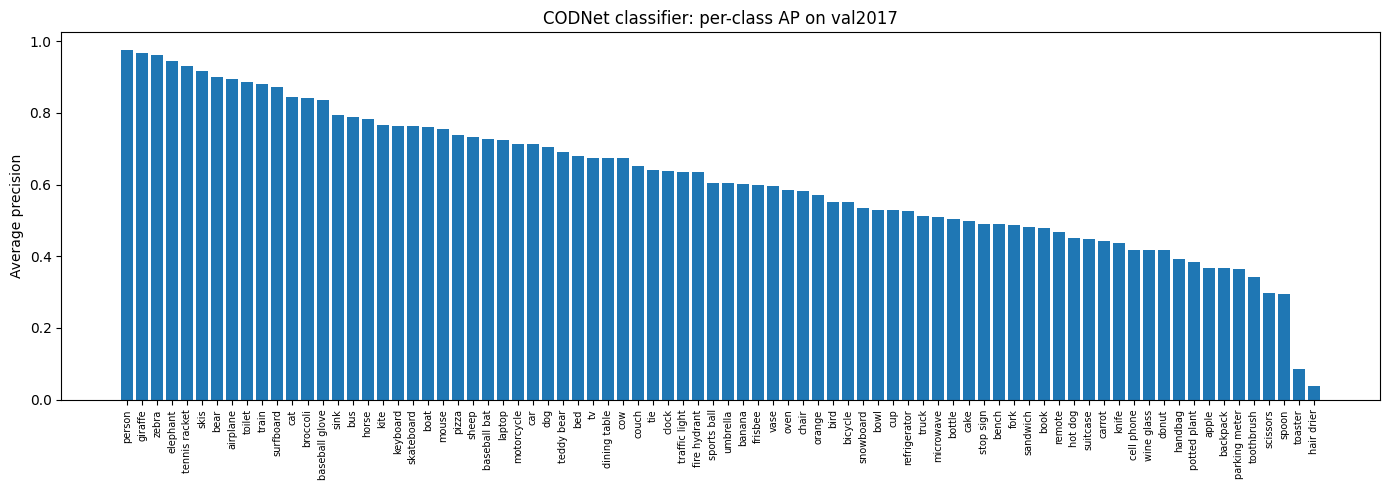

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

val_files = [f"{base}/val2017/{im['file_name']}" for im in val["images"]]
names = [c["name"] for c in sorted(val["categories"], key=lambda c: c["id"])]

best_model = CodNet().to(device)
best_model.load_state_dict(torch.load("codnet_best.pth", map_location=device))
P = predict(best_model, val_files, Y_val)

pred = (P > 0.5).astype(int)
mAP, f1_micro = metrics(P, Y_val)
f1_macro = f1_score(Y_val, pred, average="macro", zero_division=0)
acc = (pred == Y_val).mean()

print("=== FINAL TEST on val2017 (5,000 images) ===")
print(f"mAP: {mAP:.3f}")
print(f"micro-F1 @0.5: {f1_micro:.3f} | macro-F1 @0.5: {f1_macro:.3f}")
print(f"per-label accuracy (old metric): {acc*100:.2f}% | all-zeros baseline: {(1-Y_val.mean())*100:.2f}%")

ap = [average_precision_score(Y_val[:, k], P[:, k]) for k in range(80)]
df = pd.DataFrame({"class": names, "AP": ap, "n_images": Y_val.sum(0).astype(int)}).sort_values("AP", ascending=False)
df.to_csv("per_class_AP.csv", index=False)
print("\nBest 5 classes:\n", df.head(5).to_string(index=False))
print("\nWorst 5 classes:\n", df.tail(5).to_string(index=False))

plt.figure(figsize=(14, 5))
plt.bar(df["class"], df["AP"])
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("Average precision")
plt.title("CODNet classifier: per-class AP on val2017")
plt.tight_layout()
plt.savefig("per_class_AP.png", dpi=150)

# one concrete failure case: the image with the most wrong labels
errs = np.abs(pred - Y_val).sum(1)
w = int(errs.argmax())
print("\nWorst image:", val_files[w])
print("true:", [names[k] for k in np.where(Y_val[w] == 1)[0]])
print("pred:", [names[k] for k in np.where(pred[w] == 1)[0]])